<a href="https://colab.research.google.com/github/shalinisanagavarapu/Animal-Intrusion-Detection-using-YOLO-V9/blob/main/Animal_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch==2.5.0 torchvision torchaudio

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.5/906.5 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s

In [ ]:
!python -c "import torch; print(torch.__version__)"

2.5.0+cu124


In [ ]:
import shutil
import os

# Define paths
drive_dataset_path = "/content/drive/MyDrive/YOLO dataset"
colab_dataset_path = "/content/YOLO_dataset"

# Ensure the Colab dataset folder exists
os.makedirs(colab_dataset_path, exist_ok=True)

# Define zip filenames
zip_files = ["Train.zip", "Test.zip"]

# Copy zip files from YOLO dataset folder
for zip_file in zip_files:
    src = os.path.join(drive_dataset_path, zip_file)
    dest = os.path.join(colab_dataset_path, zip_file)

    if os.path.exists(src):
        print(f"📂 Copying {zip_file} to Colab (this may take a while)...")
        shutil.copy(src, dest)
        print(f"✅ {zip_file} copied successfully!")
    else:
        print(f"⚠ {zip_file} not found in YOLO dataset folder!")

📂 Copying Train.zip to Colab (this may take a while)...
✅ Train.zip copied successfully!
📂 Copying Test.zip to Colab (this may take a while)...
✅ Test.zip copied successfully!


In [ ]:
import zipfile

colab_dataset_path = "/content/YOLO_dataset"

# Extract train.zip and test.zip
for zip_file in ['Train.zip', 'Test.zip']:
    zip_path = os.path.join(colab_dataset_path, zip_file)
    extract_path = os.path.join(colab_dataset_path, zip_file.replace('.zip', ''))

    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                # Check for corruption
                if zip_ref.testzip() is not None:
                    print(f"❌ {zip_file} is corrupted! Skipping extraction.")
                    continue

                # Extract only if not already extracted
                if not os.path.exists(extract_path):
                    print(f"📦 Extracting {zip_file} (this may take a while)...")
                    zip_ref.extractall(extract_path)
                    print(f"✅ {zip_file} extracted successfully!")
                else:
                    print(f"✅ {zip_file} is already extracted!")

        except zipfile.BadZipFile:
            print(f"❌ ERROR: {zip_file} is not a valid ZIP file! Skipping extraction.")

    else:
        print(f"⚠ {zip_file} not found in Colab dataset folder!")

📦 Extracting Train.zip (this may take a while)...
✅ Train.zip extracted successfully!
📦 Extracting Test.zip (this may take a while)...
✅ Test.zip extracted successfully!


In [ ]:
print("\n📂 Extracted Dataset Structure:")
for root, dirs, files in os.walk(colab_dataset_path):
    print(f"{root}/")

    for d in dirs:
        print(f"  📁 {d}/")

    if files:
        print(f"  📄 {len(files)} files found")
        for f in files[:5]:  # Show first 5 files
            print(f"    📄 {f}")
        if len(files) > 5:
            print("    ... (more files hidden)")


📂 Extracted Dataset Structure:
/content/YOLO_dataset/
  📁 Test/
  📁 Train/
  📄 2 files found
    📄 Train.zip
    📄 Test.zip
/content/YOLO_dataset/Test/
  📁 Bear/
  📁 Sheep/
  📁 Snake/
  📁 Bull/
  📁 Elephant/
  📁 Rabbit/
  📁 Cattle/
  📁 Goat/
  📁 Deer/
  📁 Cheetah/
  📁 Tiger/
  📁 Lion/
  📁 Pig/
  📁 Monkey/
  📁 Horse/
/content/YOLO_dataset/Test/Bear/
  📁 Label/
  📄 39 files found
    📄 981ff8cfd891a39a.jpg
    📄 bb2d5daedea06da5.jpg
    📄 ab68f7a2c2575ff6.jpg
    📄 77d8f1427530d52c.jpg
    📄 b2d92399ba4b0328.jpg
    ... (more files hidden)
/content/YOLO_dataset/Test/Bear/Label/
  📄 39 files found
    📄 23bf858cb1d0ef63.txt
    📄 200046eca85cd992.txt
    📄 f0cd1050b09dd625.txt
    📄 eab56e74f42e5286.txt
    📄 50100f0b149c5668.txt
    ... (more files hidden)
/content/YOLO_dataset/Test/Sheep/
  📁 Label/
  📄 74 files found
    📄 e85d22c3bc61cf04.jpg
    📄 7fd5a774e62a93ee.jpg
    📄 4b628115bbe657a0.jpg
    📄 e3a04475047a8e28.jpg
    📄 f2dad8fd4e57adce.jpg
    ... (more files hidden)
/conten

In [ ]:
import os

# Define dataset path
dataset_path = "/content/YOLO_dataset"

# Iterate through train and test sets
for split in ["Train", "Test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n🔍 Checking {split} dataset...\n")

    # Iterate over all animal categories
    for category in os.listdir(split_path):
        category_path = os.path.join(split_path, category)

        if not os.path.isdir(category_path):
            continue  # Skip if not a directory (e.g., files like train.zip)

        image_folder = category_path
        label_folder = os.path.join(category_path, "Label")

        # Get list of image and label filenames (without extensions)
        image_files = {os.path.splitext(f)[0] for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))}
        label_files = {os.path.splitext(f)[0] for f in os.listdir(label_folder) if f.endswith('.txt')}

        # Find missing labels & images
        missing_labels = image_files - label_files  # Images without labels
        missing_images = label_files - image_files  # Labels without images

        # Print results per category
        if not missing_labels and not missing_images:
            print(f"✅ {category}: All images have corresponding label files!")
        else:
            if missing_labels:
                print(f"⚠ {category}: {len(missing_labels)} images are missing labels:")
                print(list(missing_labels)[:5], "...")  # Show only first 5 missing items
            if missing_images:
                print(f"⚠ {category}: {len(missing_images)} labels are missing images:")
                print(list(missing_images)[:5], "...")  # Show only first 5 missing items


🔍 Checking Train dataset...

✅ Bear: All images have corresponding label files!
✅ Sheep: All images have corresponding label files!
✅ Snake: All images have corresponding label files!
✅ Bull: All images have corresponding label files!
✅ Elephant: All images have corresponding label files!
✅ Rabbit: All images have corresponding label files!
✅ Cattle: All images have corresponding label files!
✅ Goat: All images have corresponding label files!
✅ Deer: All images have corresponding label files!
✅ Cheetah: All images have corresponding label files!
✅ Tiger: All images have corresponding label files!
✅ Lion: All images have corresponding label files!
✅ Pig: All images have corresponding label files!
✅ Monkey: All images have corresponding label files!
✅ Horse: All images have corresponding label files!

🔍 Checking Test dataset...

✅ Bear: All images have corresponding label files!
✅ Sheep: All images have corresponding label files!
✅ Snake: All images have corresponding label files!
✅ Bul

In [ ]:
!find /content/YOLO_dataset/Train -type f -name "*.txt" | shuf -n 3 | xargs head

==> /content/YOLO_dataset/Train/Monkey/Label/00fb055375355917.txt <==
Monkey 12.16 17.26885 919.68 684.36021

==> /content/YOLO_dataset/Train/Horse/Label/691bd42932ce0bd7.txt <==
Horse 0.0 40.32 948.48 767.360256

==> /content/YOLO_dataset/Train/Snake/Label/0a2a47cfbb2bc25c.txt <==
Snake 0.0 33.599846 567.9564799999999 319.200056


In [ ]:
import cv2
import os

base_image_folder = "/content/YOLO_dataset/Train"

# Loop through all category folders
for category in os.listdir(base_image_folder):
    category_path = os.path.join(base_image_folder, category, "images")  # Updated path

    if os.path.exists(category_path):  # Ensure the 'images' folder exists
        for img_file in os.listdir(category_path):
            img_path = os.path.join(category_path, img_file)
            img = cv2.imread(img_path)
            if img is None:
                print(f"❌ Corrupt image: {img_path}")

In [ ]:
import os
import shutil

# Define original dataset paths
original_dataset_path = "/content/YOLO_dataset"
train_path = os.path.join(original_dataset_path, "Train")
test_path = os.path.join(original_dataset_path, "Test")

# Define a new folder for the copied dataset
new_dataset_path = "/content/Formatted_dataset"
new_train_path = os.path.join(new_dataset_path, "Train")
new_test_path = os.path.join(new_dataset_path, "Test")

# Ensure new dataset folders exist
for path in [new_train_path, new_test_path]:
    os.makedirs(os.path.join(path, "images"), exist_ok=True)
    os.makedirs(os.path.join(path, "labels"), exist_ok=True)

# Function to reorganize images and labels
def organize_and_copy_data(src_base_path, dest_base_path):
    for class_folder in os.listdir(src_base_path):  # Iterate through class subfolders
        class_folder_path = os.path.join(src_base_path, class_folder)

        if os.path.isdir(class_folder_path):  # Ensure it's a folder
            for item in os.listdir(class_folder_path):
                item_path = os.path.join(class_folder_path, item)

                if item.endswith((".jpg", ".png", ".jpeg")):  # Copy images
                    shutil.copy(item_path, os.path.join(dest_base_path, "images", item))

                elif os.path.isdir(item_path) and item == "Label":  # Handle label subfolder
                    for label_file in os.listdir(item_path):
                        if label_file.endswith(".txt"):
                            shutil.copy(os.path.join(item_path, label_file), os.path.join(dest_base_path, "labels", label_file))

# Run for Train and Test datasets
organize_and_copy_data(train_path, new_train_path)
organize_and_copy_data(test_path, new_test_path)

print("✅ Images and labels copied successfully to Formatted_dataset!")

✅ Images and labels copied successfully to Formatted_dataset!


In [ ]:
import os

dataset_path = "/content/Formatted_dataset"

for split in ["Train", "Test"]:
    img_path = os.path.join(dataset_path, split, "images")
    lbl_path = os.path.join(dataset_path, split, "labels")

    print(f"📂 {split} - Images: {len(os.listdir(img_path))}, Labels: {len(os.listdir(lbl_path))}")


📂 Train - Images: 3747, Labels: 3747
📂 Test - Images: 1644, Labels: 1644


In [ ]:
import os
from PIL import Image

# Define paths
dataset_path = "/content/Formatted_dataset"
train_labels_path = os.path.join(dataset_path, "Train", "labels")
test_labels_path = os.path.join(dataset_path, "Test", "labels")

# Function to extract class names from label files
def get_class_names(label_folder):
    class_names = set()

    for label_file in os.listdir(label_folder):
        label_path = os.path.join(label_folder, label_file)

        with open(label_path, "r") as file:
            lines = file.readlines()
            for line in lines:
                class_name = line.strip().split()[0]  # Extract first element (class name)
                class_names.add(class_name)  # Store unique class names

    return sorted(list(class_names))  # Return sorted list of class names

# Extract class names from training labels
class_names = get_class_names(train_labels_path)
num_classes = len(class_names)

# Print detected class names
print("✅ Detected Classes:", class_names)

# Function to convert label format with correct normalization
def convert_labels(label_folder, image_folder):
    for label_file in os.listdir(label_folder):
        label_path = os.path.join(label_folder, label_file)
        image_path = os.path.join(image_folder, label_file.replace(".txt", ".jpg"))  # Assuming JPG format

        if not os.path.exists(image_path):
            print(f"⚠ Warning: Image file not found for {label_file}")
            continue

        # Get actual image size
        with Image.open(image_path) as img:
            image_width, image_height = img.size

        with open(label_path, "r") as file:
            lines = file.readlines()

        new_lines = []
        for line in lines:
            data = line.strip().split()
            class_name = data[0]

            if class_name not in class_names:
                print(f"⚠ Warning: Class '{class_name}' not found in detected classes!")
                continue  # Skip unknown classes

            class_id = class_names.index(class_name)  # Convert class name to ID
            x_min, y_min, x_max, y_max = map(float, data[1:])  # Convert to float

            # Convert to YOLO format (normalize coordinates)
            x_center = (x_min + x_max) / (2 * image_width)
            y_center = (y_min + y_max) / (2 * image_height)
            width = (x_max - x_min) / image_width
            height = (y_max - y_min) / image_height

            # Ensure values are within [0,1]
            x_center = max(0, min(x_center, 1))
            y_center = max(0, min(y_center, 1))
            width = max(0, min(width, 1))
            height = max(0, min(height, 1))

            new_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

        # Save the updated label file
        with open(label_path, "w") as file:
            file.writelines(new_lines)

# Convert labels for both Train and Test datasets
convert_labels(train_labels_path, os.path.join(dataset_path, "Train", "images"))
convert_labels(test_labels_path, os.path.join(dataset_path, "Test", "images"))

# Create dataset.yaml
yaml_content = f"""train: {os.path.join(dataset_path, 'Train', 'images')}
val: {os.path.join(dataset_path, 'Test', 'images')}
test: {os.path.join(dataset_path, 'Test', 'images')}

nc: {num_classes}
names: {class_names}
"""

yaml_path = os.path.join(dataset_path, "dataset.yaml")
with open(yaml_path, "w") as file:
    file.write(yaml_content)

print("✅ Labels successfully converted & dataset.yaml created!")


✅ Detected Classes: ['Bear', 'Bull', 'Cattle', 'Cheetah', 'Deer', 'Elephant', 'Goat', 'Horse', 'Lion', 'Monkey', 'Pig', 'Rabbit', 'Sheep', 'Snake', 'Tiger']
✅ Labels successfully converted & dataset.yaml created!


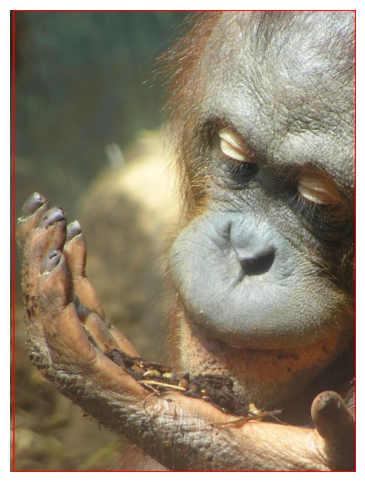

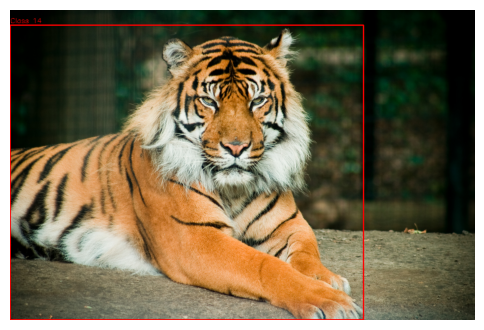

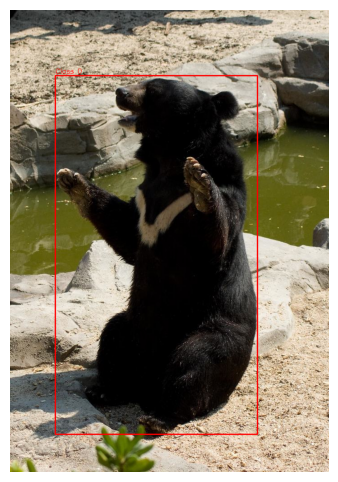

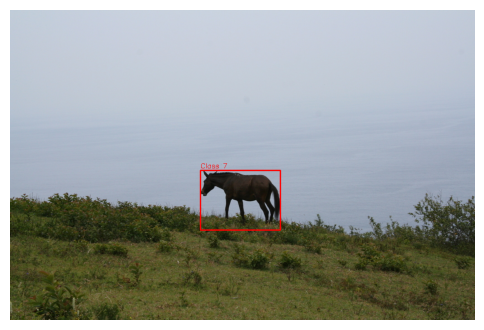

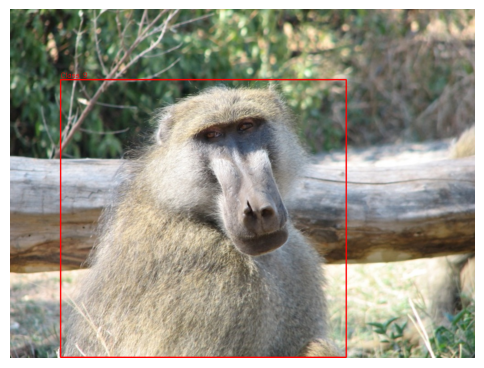

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Define dataset paths
dataset_path = "/content/Formatted_dataset"
subsets = ["Train", "Test"]  # Modify if you have different subfolder names

# Function to visualize dataset
def visualize_dataset(subset="Train", num_images=5):
    images_path = os.path.join(dataset_path, subset, "images")
    labels_path = os.path.join(dataset_path, subset, "labels")

    image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

    for img_file in image_files[:num_images]:
        img_path = os.path.join(images_path, img_file)
        label_file = os.path.join(labels_path, os.path.splitext(img_file)[0] + ".txt")

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                for line in f.readlines():
                    data = line.strip().split()
                    class_id = int(data[0])
                    x_center, y_center, width, height = map(float, data[1:])

                    # Convert YOLO format to pixel coordinates
                    h, w, _ = img.shape
                    x1 = int((x_center - width / 2) * w)
                    y1 = int((y_center - height / 2) * h)
                    x2 = int((x_center + width / 2) * w)
                    y2 = int((y_center + height / 2) * h)

                    # Draw bounding box
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, f"Class {class_id}", (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        # Display the image
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

# Call function to visualize training images
visualize_dataset("Train", num_images=5)


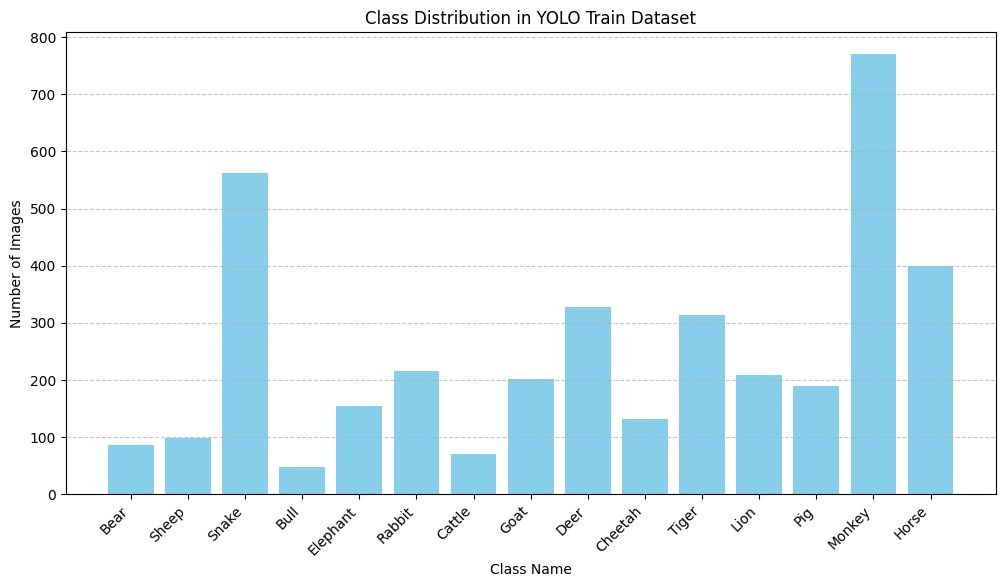

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Define dataset path
dataset_path = "/content/YOLO_dataset/Train"

# Get all class folders
class_counts = Counter()

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    # Ensure it's a directory
    if os.path.isdir(class_path):
        images_count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        class_counts[class_name] = images_count

# Plot histogram
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.title("Class Distribution in YOLO Train Dataset")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better visibility
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


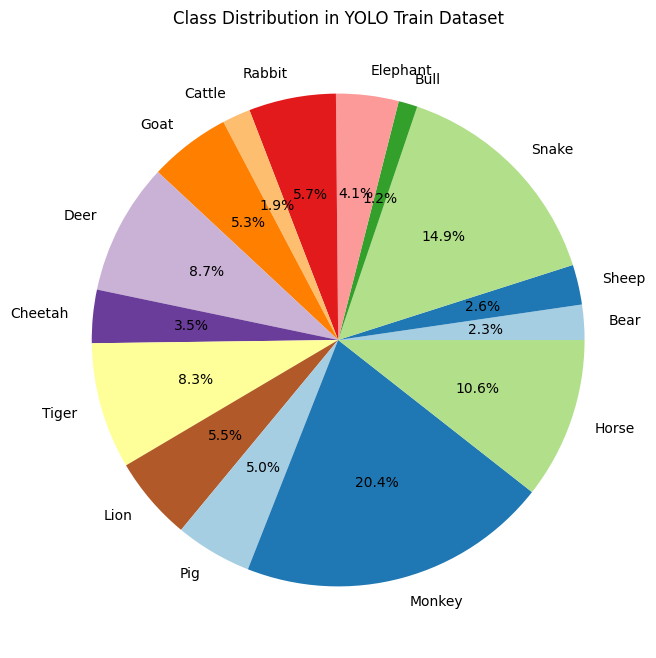

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct="%1.1f%%", colors=plt.cm.Paired.colors)
plt.title("Class Distribution in YOLO Train Dataset")
plt.show()

In [ ]:
!nvidia-smi

Mon Mar 17 17:12:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/SkalskiP/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q

Cloning into 'yolov9'...
remote: Enumerating objects: 325, done.
remote: Total 325 (delta 0), reused 0 (delta 0), pack-reused 325 (from 1)
Receiving objects: 100% (325/325), 2.25 MiB | 4.62 MiB/s, done.
Resolving deltas: 100% (162/162), done.
/content/yolov9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.2 MB/s eta 0:00:00


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content/yolov9


In [ ]:
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-e.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-e.pt

In [ ]:
!ls -la {HOME}/weights

total 402444
drwxr-xr-x  2 root root      4096 Mar 17 17:12 .
drwxr-xr-x 12 root root      4096 Mar 17 17:12 ..
-rw-r--r--  1 root root  51508261 Feb 18  2024 gelan-c.pt
-rw-r--r--  1 root root 117203713 Feb 18  2024 gelan-e.pt
-rw-r--r--  1 root root 103153312 Feb 18  2024 yolov9-c.pt
-rw-r--r--  1 root root 140217688 Feb 18  2024 yolov9-e.pt


In [ ]:
import torch

weight_path = "/content/yolov9/weights/gelan-c.pt"  # Change filename if needed

try:
    model_weights = torch.load(weight_path, map_location="cpu", weights_only=False)
    print("Weights loaded successfully!")
except Exception as e:
    print(f"Error loading weights: {e}")


Weights loaded successfully!


In [ ]:
%cd {HOME}

!python train.py \
--batch 16 --epochs 25 --img 640 --device 0 --min-items 0 --close-mosaic 15 \
--data /content/Formatted_dataset/dataset.yaml \
--weights weights/gelan-c.pt \
--cfg models/detect/gelan-c.yaml \
--hyp data/hyps/hyp.optimized.yaml

/content/yolov9
2025-03-17 17:21:07.183429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742232067.204013    5998 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742232067.210678    5998 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-17 17:21:07.232001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more inf

In [ ]:
!ls {HOME}/runs/train/exp2/

confusion_matrix.png				    labels_correlogram.jpg  PR_curve.png  weights
events.out.tfevents.1742232074.249602d50f8f.5998.0  labels.jpg		    R_curve.png
F1_curve.png					    opt.yaml		    results.csv
hyp.yaml					    P_curve.png		    results.png


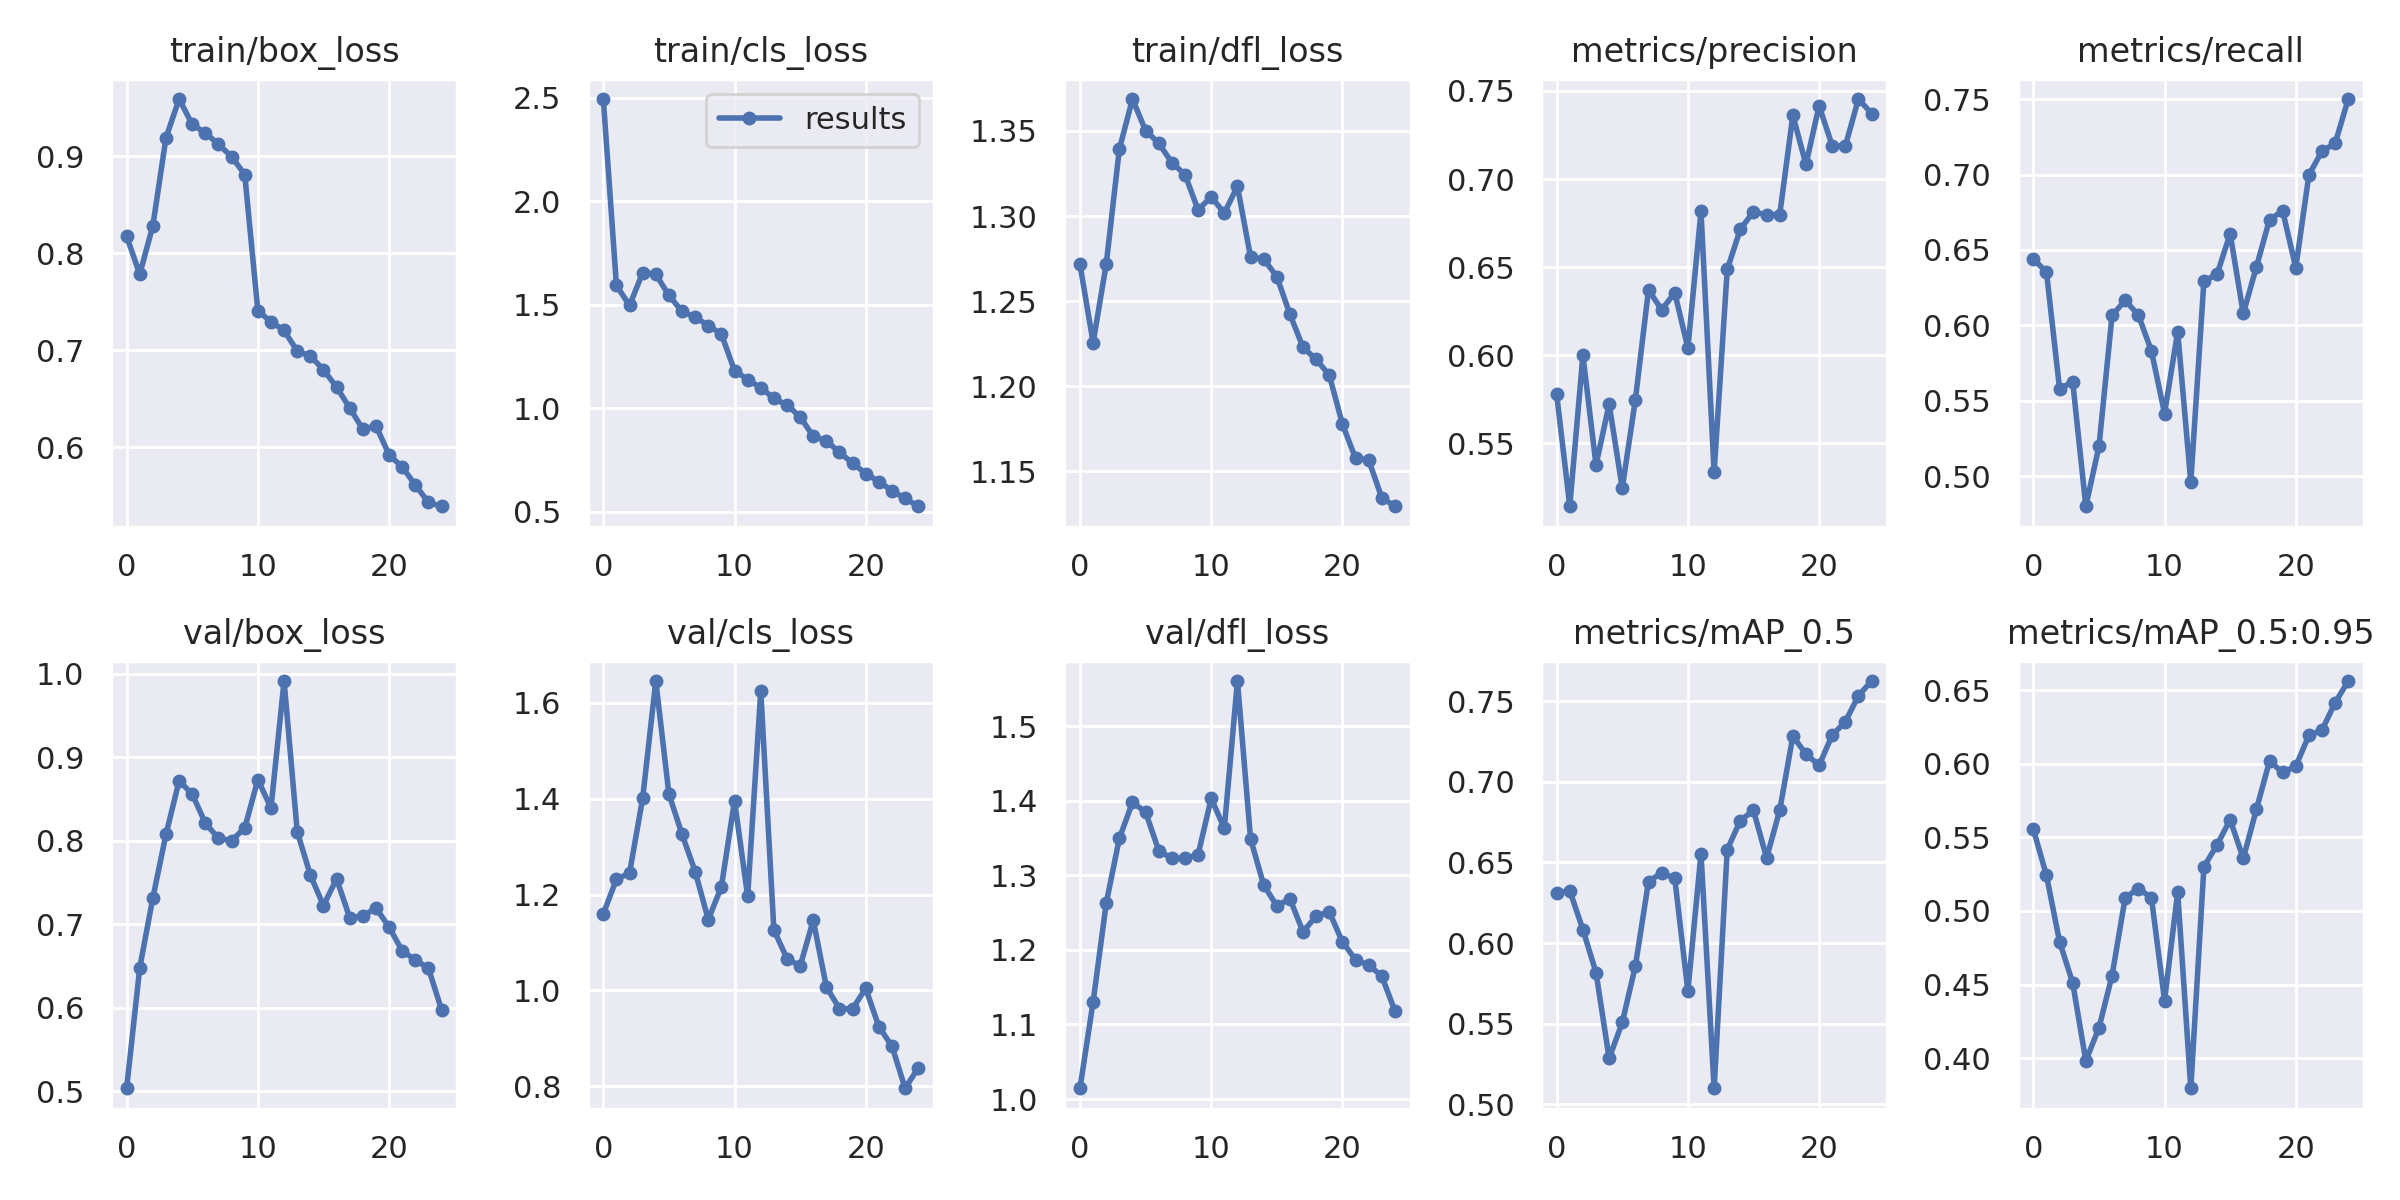

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/runs/train/exp2/results.png", width=1000)

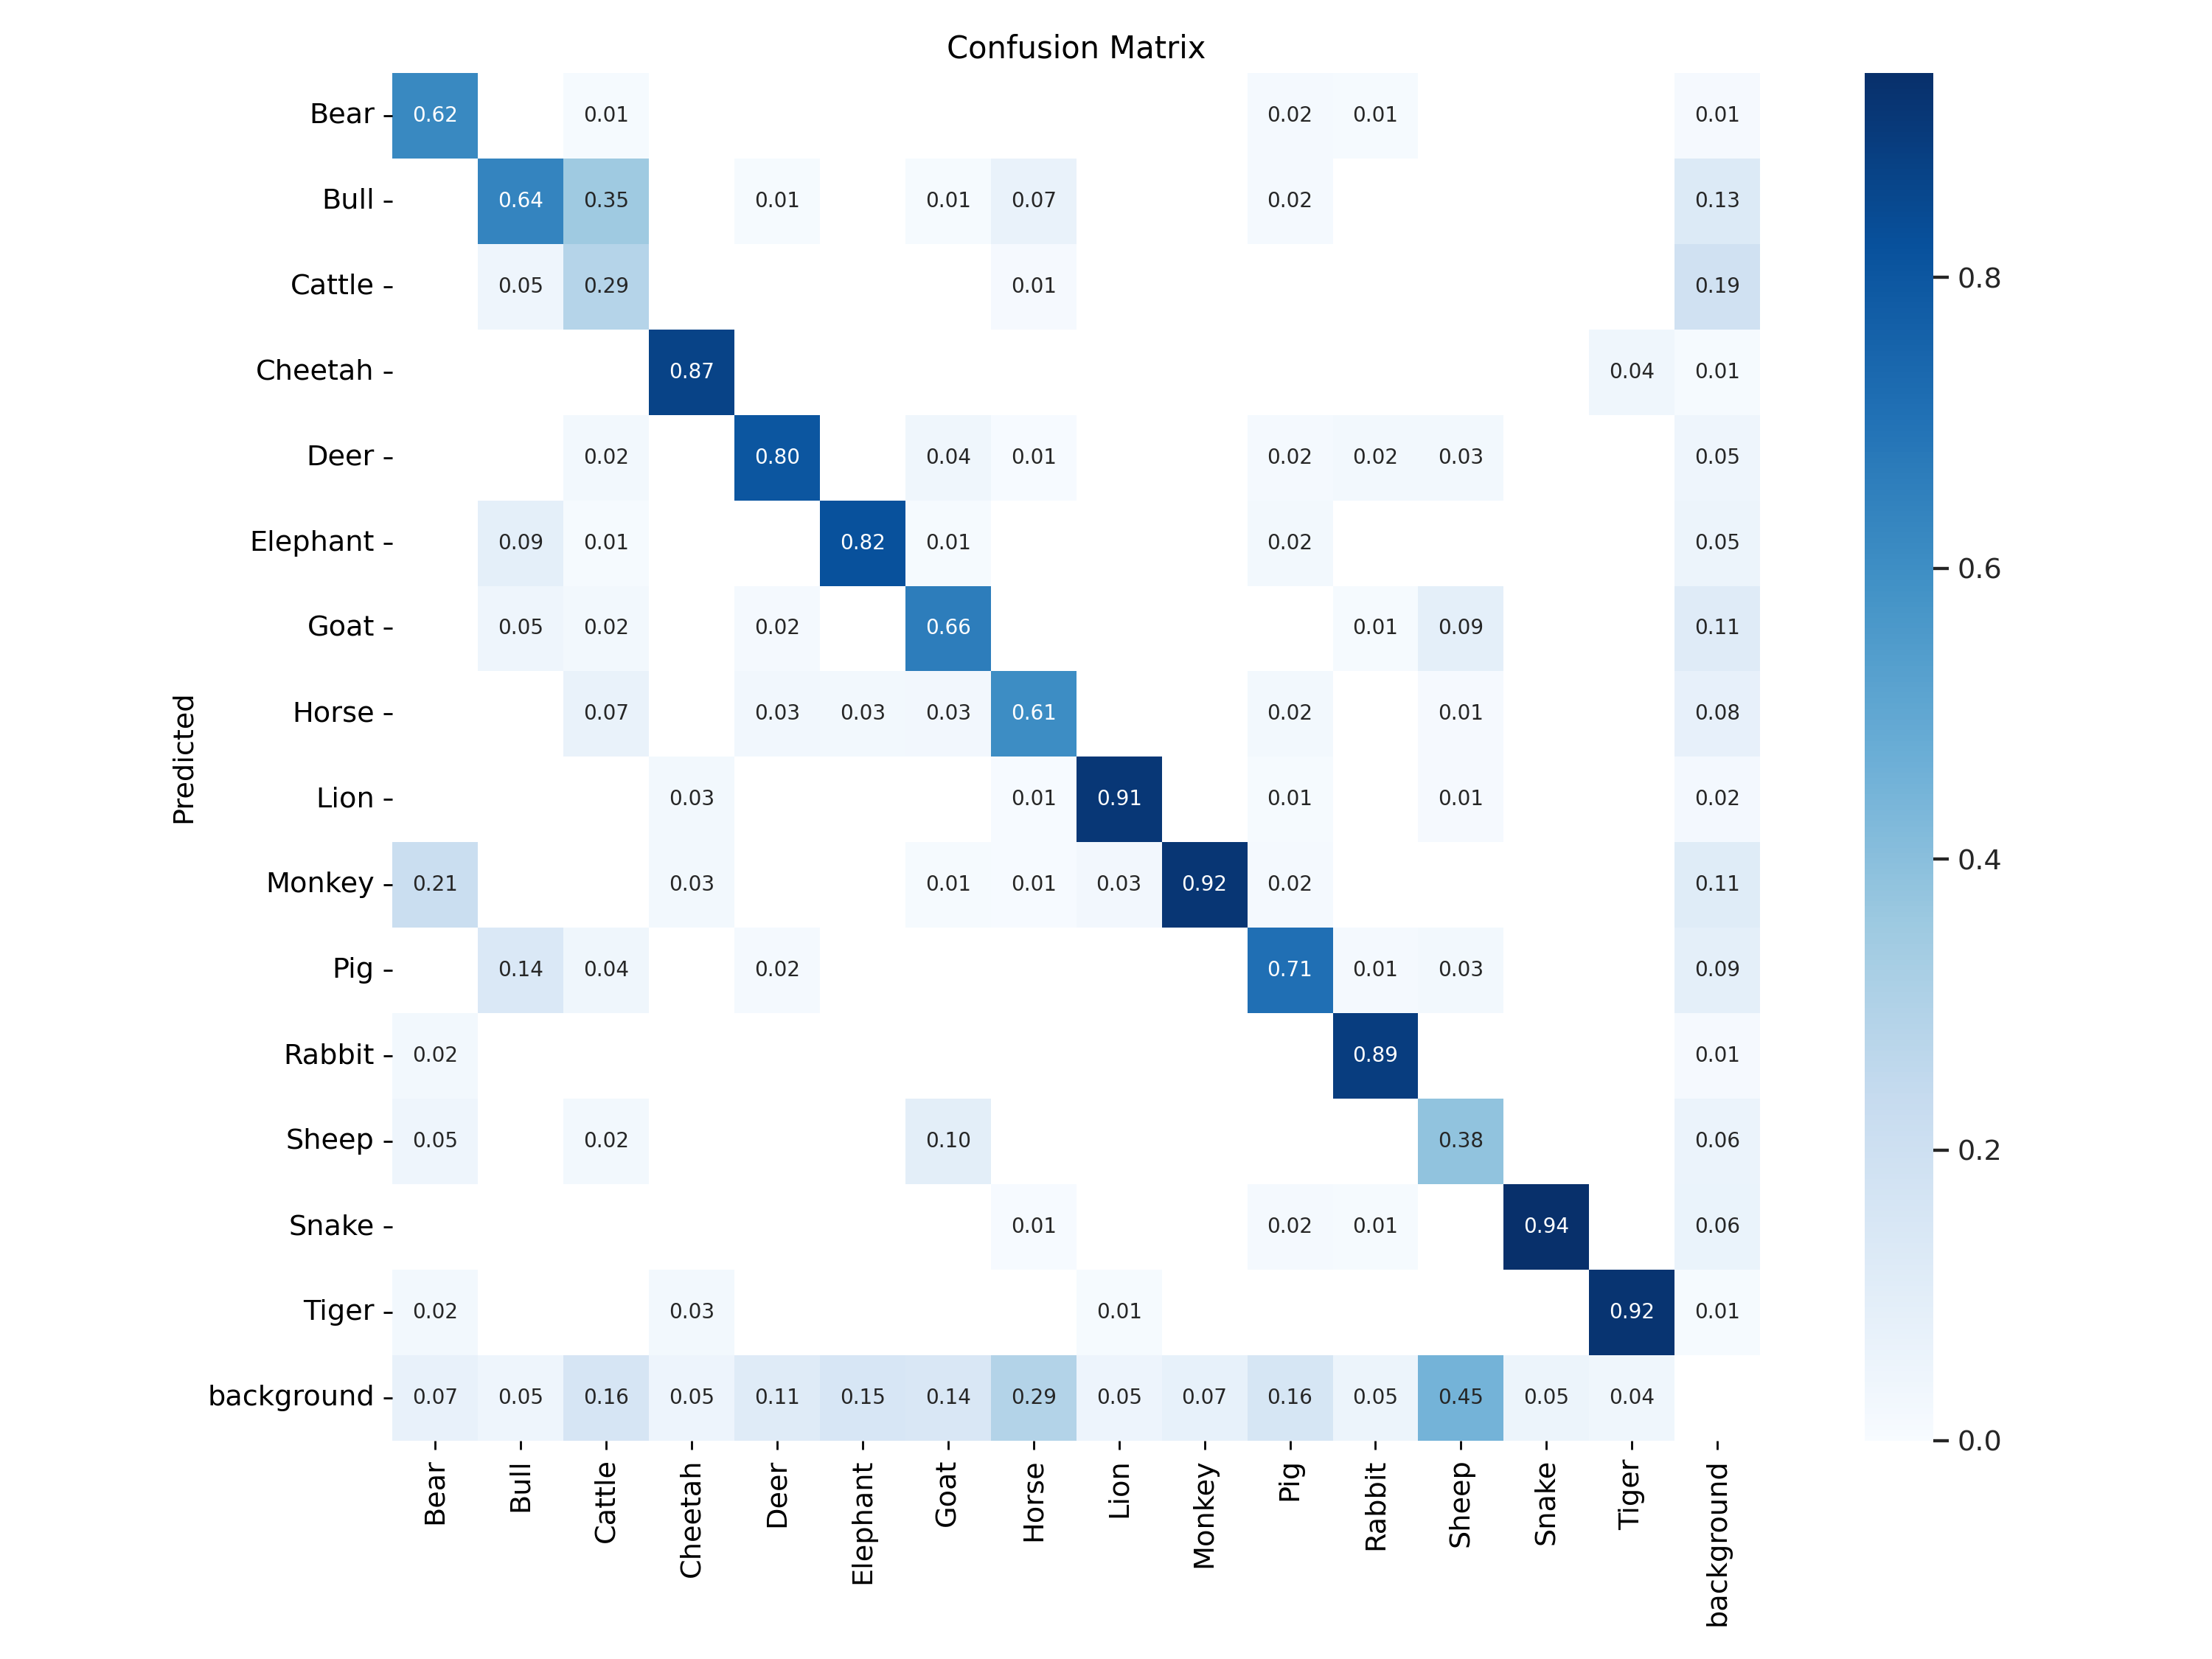

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/runs/train/exp2/confusion_matrix.png", width=1000)

In [ ]:
%cd {HOME}
!python val.py \
--img 640 --batch 32 --conf 0.001 --iou 0.7 --device 0 \
--data /content/Formatted_dataset/dataset.yaml \
--weights {HOME}/runs/train/exp2/weights/best.pt

/content/yolov9
val: data=/content/Formatted_dataset/dataset.yaml, weights=['/content/yolov9/runs/train/exp2/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLOv5 🚀 1e33dbb Python-3.11.11 torch-2.5.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

/content/yolov9/models/experimental.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the func

In [ ]:
!python detect.py \
--img 1280 --conf 0.1 --device 0 \
--weights {HOME}/runs/train/exp2/weights/best.pt \
--source /content/Formatted_dataset/Test/images

detect: weights=['/content/yolov9/runs/train/exp2/weights/best.pt'], source=/content/Formatted_dataset/Test/images, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.11.11 torch-2.5.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

/content/yolov9/models/experimental.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release

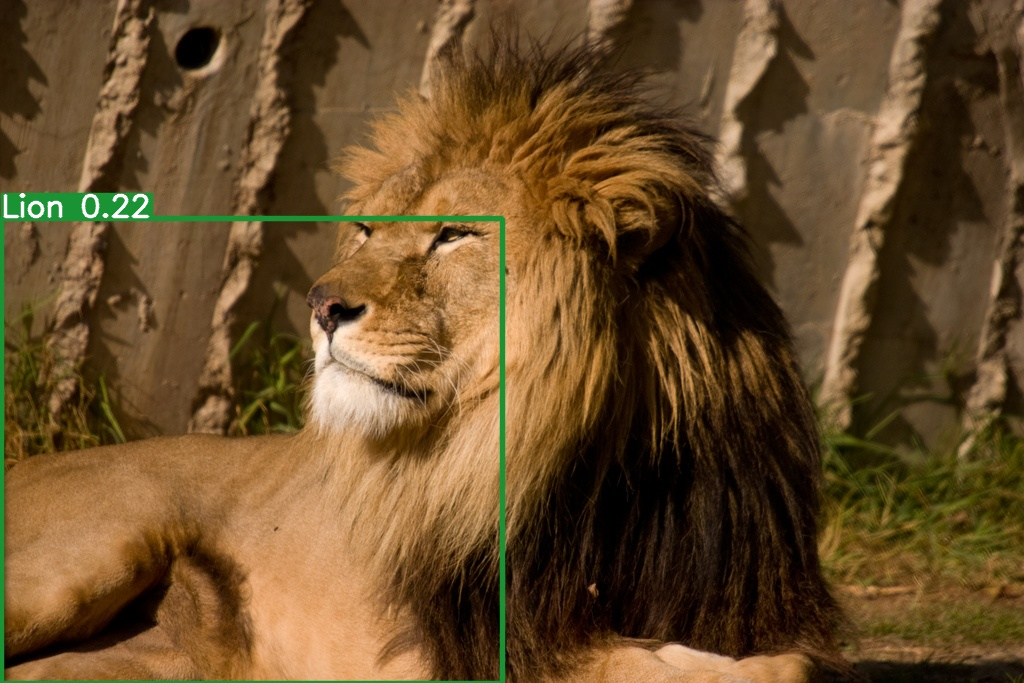

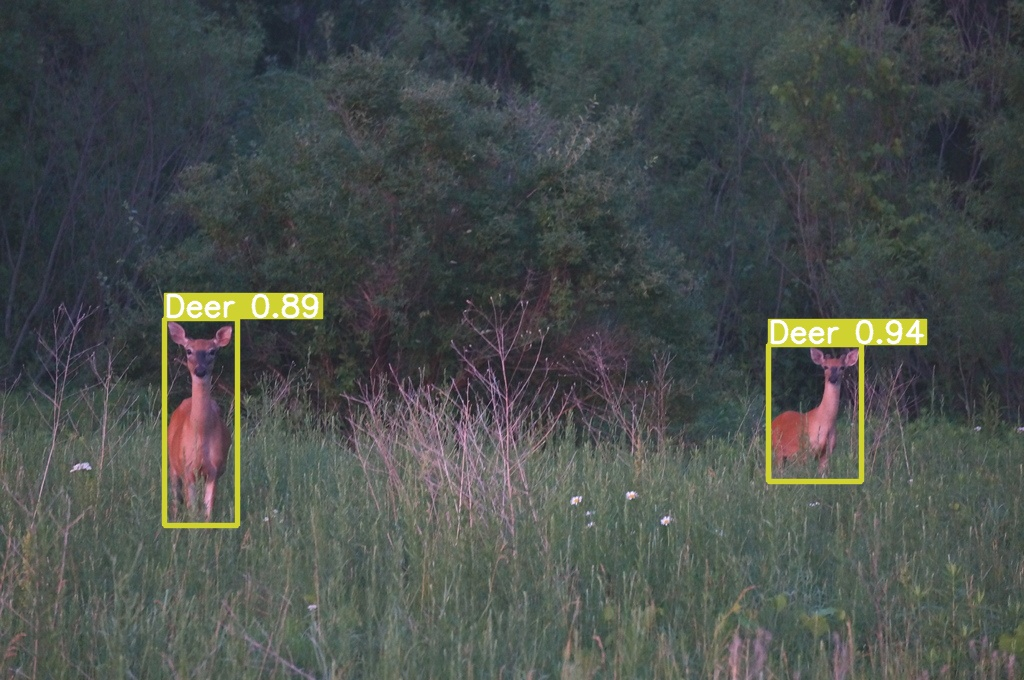

In [ ]:
import glob

from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/detect/exp/*.jpg')[:2]:
      display(Image(filename=image_path, width=600))